In [ ]:
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Tiến hành import thư viện để xử lí
import pandas as pd
import numpy as np
import json
from collections import defaultdict
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [66]:
# %%
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")

# Xem các bảng trong database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)
print(tables)

              name
0   NearsestSample
1  sqlite_sequence


In [67]:
# %%
df = pd.read_sql("SELECT * FROM NearsestSample", conn)
# %%
df = df[(df["TimeDim"] >= 2010) & (df["TimeDim"] <= 2015)].reset_index()

df.head()

,index,id,y,x1,x2,x3,x4,x5,x6,x7,x8,x9,SpatialDim,TimeDim
0,5,6,134.9,29.965,23.820369,26.1,5.0,7.200000,7.9,NaN,24.705610,28.1,ALB,2010
1,16,17,136.1,56.000,11.373624,26.6,4.9,54.178596,8.4,0.18,25.515699,7.4,ALB,2015
2,19,20,135.9,58.052,11.438215,26.5,4.9,7.700000,8.4,0.17,25.326576,7.4,ALB,2014
3,29,30,135.6,481.645,22.734497,26.4,5.0,7.600000,8.3,0.18,25.150570,7.4,ALB,2013
4,36,37,135.2,561.071,11.987971,26.2,5.0,7.300000,8.0,NaN,17.841043,28.1,ALB,2011


In [68]:
# %%
df = df.drop(columns=["index","id","x7","SpatialDim"], errors="ignore")
tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'time']
df.columns = tables
df.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
0,134.9,29.965,23.820369,26.1,5.0,7.200000,7.9,24.705610,28.1,2010
1,136.1,56.000,11.373624,26.6,4.9,54.178596,8.4,25.515699,7.4,2015
2,135.9,58.052,11.438215,26.5,4.9,7.700000,8.4,25.326576,7.4,2014
3,135.6,481.645,22.734497,26.4,5.0,7.600000,8.3,25.150570,7.4,2013
4,135.2,561.071,11.987971,26.2,5.0,7.300000,8.0,17.841043,28.1,2011


In [69]:
# %%
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10956 entries, 0 to 10955
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cardiovascular_diseases  10956 non-null  float64
 1   air_pollution            10890 non-null  float64
 2   alcohol_consumption      10735 non-null  float64
 3   BMI                      10956 non-null  float64
 4   cholesterol              10956 non-null  float64
 5   diabetes                 10956 non-null  float64
 6   glucose                  10956 non-null  float64
 7   physical_activities      10956 non-null  float64
 8   tobacco                  10956 non-null  float64
 9   time                     10956 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 856.1 KB


In [70]:
# %%
df.isnull().sum()

cardiovascular_diseases      0
air_pollution               66
alcohol_consumption        221
BMI                          0
cholesterol                  0
diabetes                     0
glucose                      0
physical_activities          0
tobacco                      0
time                         0
dtype: int64

In [71]:
# %%
df = df.fillna(df.mean(numeric_only=True))

In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10956.0,55.593244,35.512469,8.701838,32.768090,40.400000,62.100000,1.375000e+02
air_pollution,10956.0,8290.686407,319532.735705,0.000000,51.066000,193.716500,582.009500,2.509519e+07
alcohol_consumption,10956.0,41.429338,19.257525,2.680089,26.664454,40.181983,52.406960,9.921560e+01
BMI,10956.0,22.424149,17.616987,0.238787,7.450371,22.200000,27.200000,9.247079e+01
cholesterol,10956.0,2.903514,1.426160,0.800000,1.300000,3.300000,4.000000,5.300000e+00
diabetes,10956.0,16.683322,16.735358,2.800000,5.694480,8.000000,20.600000,8.310288e+01
glucose,10956.0,8.657804,4.239293,2.100000,5.900000,8.000000,9.800000,2.980000e+01
physical_activities,10956.0,26.063816,11.766169,3.335438,17.580842,23.772923,32.636906,6.920515e+01
tobacco,10956.0,23.755696,14.737694,0.000000,12.475000,23.000000,32.800000,7.700000e+01
time,10956.0,2012.500000,1.707903,2010.000000,2011.000000,2012.500000,2014.000000,2.015000e+03


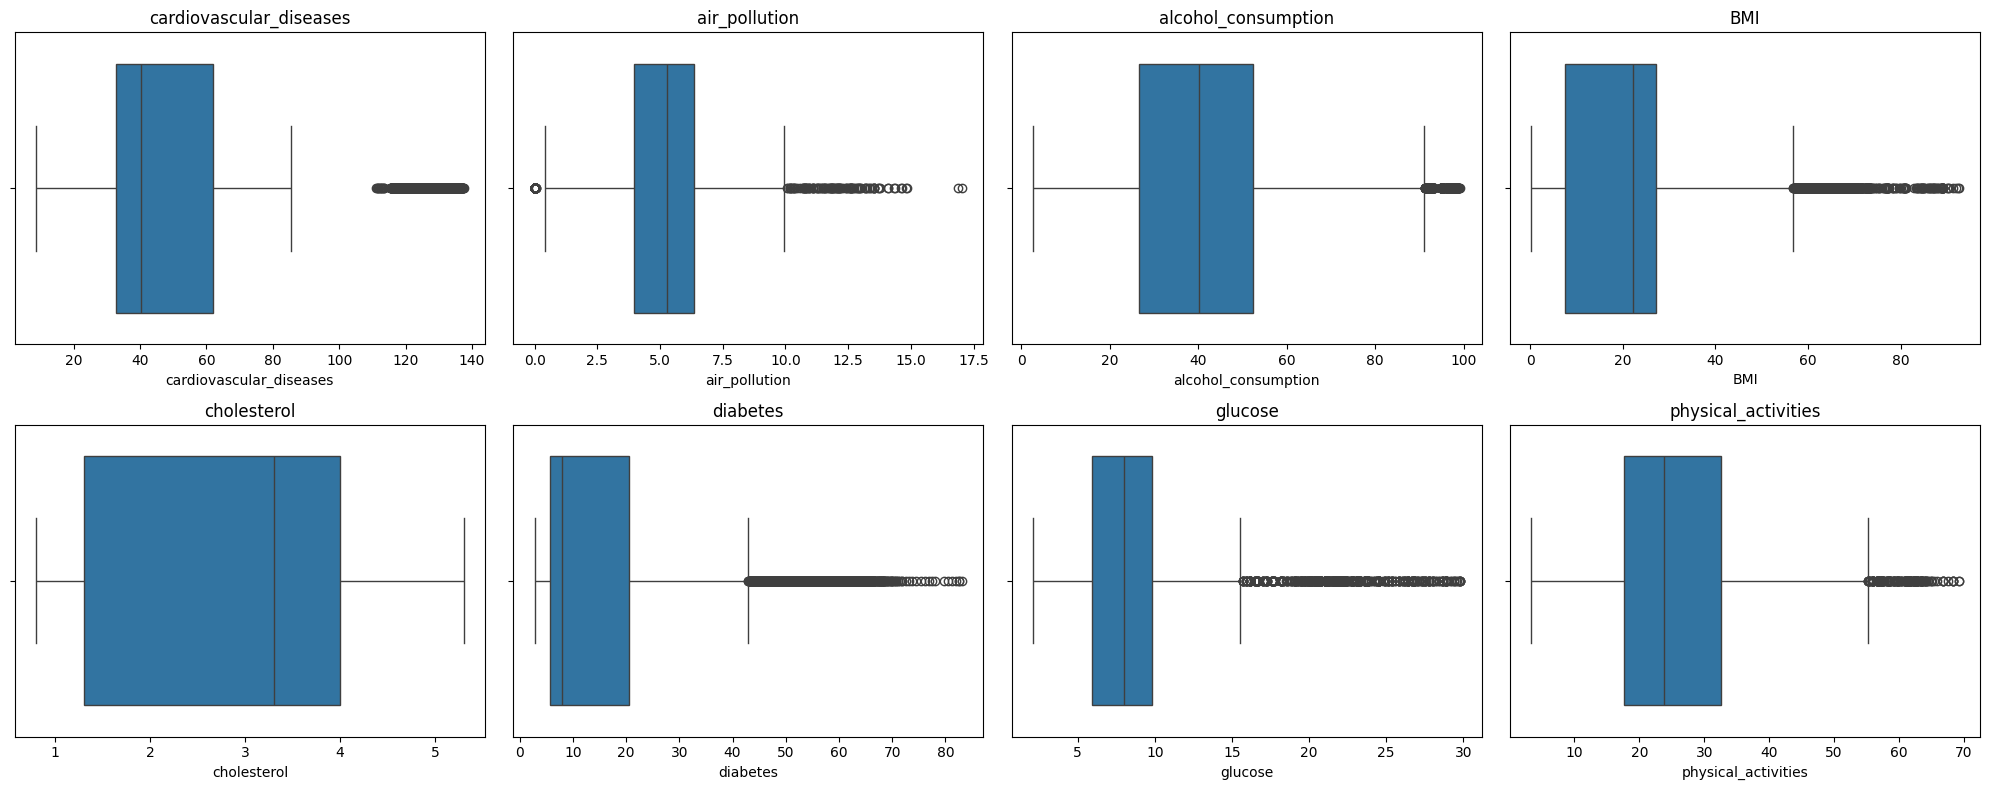

In [73]:
df.air_pollution = np.log1p(df.air_pollution)
cols = df.columns[:-1]   # bỏ cột cuối

plt.figure(figsize=(20,8))

for i, col in enumerate(cols[:8]):   # lấy 8 cột đầu
    plt.subplot(2, 4, i+1)           # 2 hàng 4 cột
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [74]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

cardiovascular_diseases : 1992
air_pollution : 393
alcohol_consumption : 212
BMI : 747
cholesterol : 0
diabetes : 1433
glucose : 610
physical_activities : 227
tobacco : 42
time : 0


In [75]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,6576.0,40.377069,13.955426,8.701838,31.399075,37.462877,47.000000,85.600000
air_pollution,6576.0,5.264960,1.584428,0.420025,4.119707,5.447711,6.416712,9.023009
alcohol_consumption,6576.0,41.402732,19.353397,2.680089,26.443872,40.273541,53.910278,93.388335
BMI,6576.0,19.264754,14.891706,0.476396,6.697595,17.398698,26.078159,60.320532
cholesterol,6576.0,2.631356,1.418008,0.800000,1.200000,2.800000,3.800000,5.300000
diabetes,6576.0,11.145188,9.750385,2.800000,5.379665,6.800000,12.000000,45.472947
glucose,6576.0,7.553406,2.645659,2.100000,5.300000,7.600000,9.300000,15.500000
physical_activities,6576.0,23.088198,9.660050,3.335438,16.171862,21.624691,28.535833,49.550209
tobacco,6576.0,22.676566,14.516079,0.000000,10.500000,22.100000,31.700000,60.000000
time,6576.0,2012.489811,1.722114,2010.000000,2011.000000,2012.000000,2014.000000,2015.000000


In [76]:
# Tiến hành chia dữ liệu
df_model = df.copy()
y = df_model['cardiovascular_diseases']
df_model.drop(columns=['cardiovascular_diseases', 'time'], inplace=True)
X = df_model

In [77]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X, y):
    # Ko cần chia để test
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [78]:
coef, inter = run_for_linear(X, y)

MSE: 160.99128197143114
R2: 0.17323478744493104
Coefficients: [-0.26546288 -0.14046585  0.02452781  2.1454936  -0.14300869  1.08211482
  0.03285404 -0.02867477]
Intercept: 34.784220764273144


In [79]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

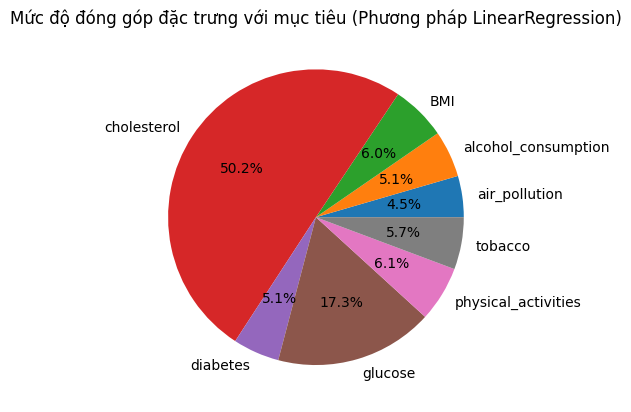

In [80]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu
plt.figure()
plt.pie(softmax(coef), labels=X.columns, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [81]:
def run_for_random_forest(X, y):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [82]:
impor = run_for_random_forest(X, y)

MSE: 8.651723058786162
R2: 0.9555693726637057
Feature Importances: [0.04256742 0.09867243 0.28156056 0.22951115 0.10283702 0.11185334
 0.07130994 0.06168814]


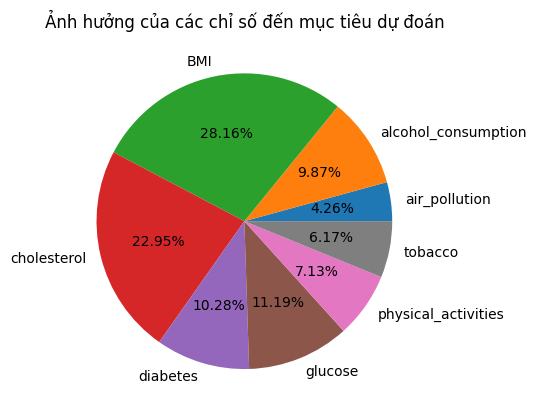

In [83]:
plt.figure()
plt.pie(impor.tolist(), labels=X.columns, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [84]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(X.columns, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

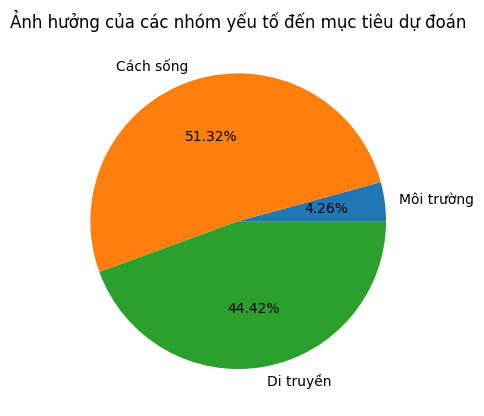

In [85]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [86]:
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
scaler = StandardScaler()
features = [
    "air_pollution",
    "alcohol_consumption",
    "BMI",
    "cholesterol",
    "diabetes",
    "glucose",
    "physical_activities",
    "tobacco"
]
# Chỉ chuẩn hóa các cột số
# numeric_cols = df.select_dtypes(include=np.number).columns

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
12,49.8,-0.786761,-0.907201,0.485894,-0.938964,-0.414906,0.131015,0.181198,-0.990464,2011
13,39.1,-1.522323,0.113963,0.506041,-0.938964,-0.384136,0.282217,-0.115738,0.194519,2014
14,49.2,0.273762,-1.153243,0.479179,-0.938964,-0.414906,0.055413,-0.195366,-0.990464,2010
15,37.4,0.824819,-0.891677,-1.198640,1.670529,-0.622156,0.282217,0.155455,-0.990464,2011
17,38.0,-1.432978,-1.532896,0.492610,-0.938964,-0.404649,0.168815,-0.158952,-0.990464,2012


In [87]:
# %%
corr_matrix = df_scaled[features].corr()

corr_matrix

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco
air_pollution,1.000000,0.105231,-0.048144,-0.049422,0.055301,-0.106133,-0.096803,-0.054982
alcohol_consumption,0.105231,1.000000,-0.107927,-0.087760,-0.002956,-0.202366,-0.180460,-0.136544
BMI,-0.048144,-0.107927,1.000000,-0.149383,-0.134081,0.182152,0.145693,0.025465
cholesterol,-0.049422,-0.087760,-0.149383,1.000000,0.003784,0.110271,0.068252,0.059226
diabetes,0.055301,-0.002956,-0.134081,0.003784,1.000000,0.180081,0.037079,0.004337
glucose,-0.106133,-0.202366,0.182152,0.110271,0.180081,1.000000,0.387355,0.185325
physical_activities,-0.096803,-0.180460,0.145693,0.068252,0.037079,0.387355,1.000000,0.061878
tobacco,-0.054982,-0.136544,0.025465,0.059226,0.004337,0.185325,0.061878,1.000000


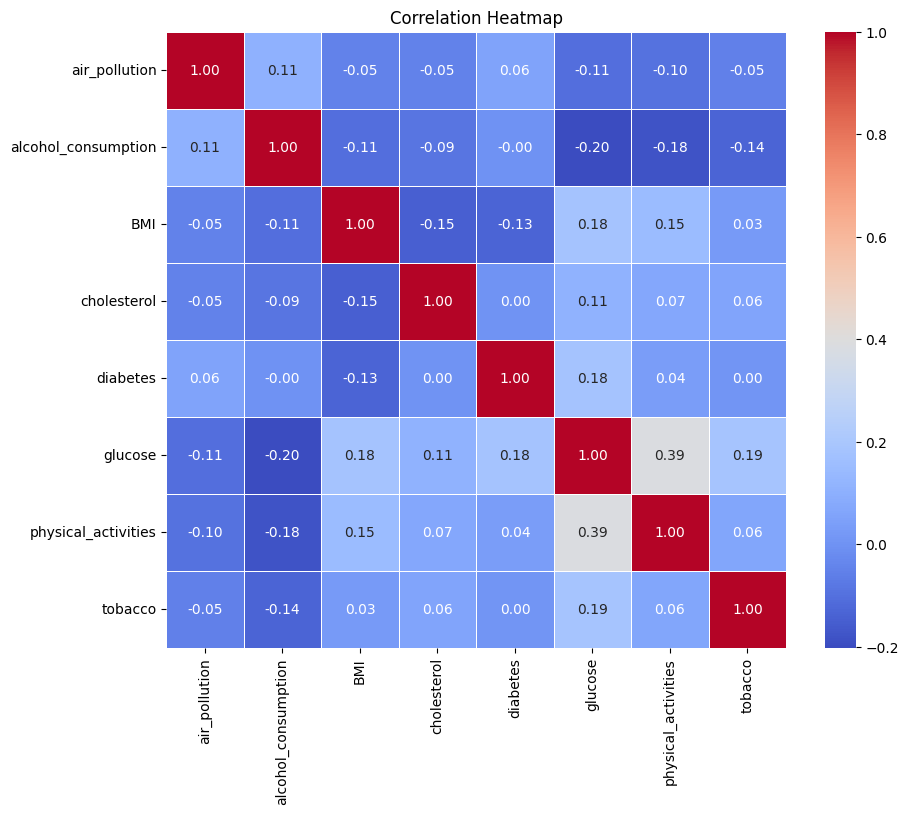

In [88]:
# %%
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()